In [ ]:
# 프로젝트 1

In [ ]:
## sklearn dt 가져오기, 입력 데이터 x와, 목표값 y를 설정

In [1]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
df_X = data.data
df_y = data.target

In [ ]:
## 모델에 x값을 np array로 변경
(숫자 계산만 빠르고 정확하게 하도록)

In [2]:
import numpy as np

X = np.array(df_X)

print(type(X), X.dtype)

<class 'numpy.ndarray'> float64


In [ ]:
## 모델에 y값을 np array로 변경

In [3]:
y = np.array(df_y)

print(type(y), y.dtype)

<class 'numpy.ndarray'> float64


In [ ]:
## x와 y를 각각 Train 데이터와 Test 데이터로 분리하기
Train 데이터: for 모델 학습
Test 데이터: for 평가(테스트를 위함)
[참고: 시험을 준비하는 학생이 있다고 해봅시다.
    
Train 데이터 → 공부할 때 보는 문제
Test 데이터 → 실제 시험 문제

학생에게 시험 문제와 똑같은 문제를 미리 전부 보여주고 시험을 보면 점수가 높게 나오겠죠.

하지만 그건 실력이 좋아서가 아니라 문제를 외웠기 때문일 수도 있습니다.]

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


In [ ]:
## 모델 준비 (모델이 학습을 시작하도록)

In [5]:
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))

10


In [ ]:
## 가중치(W)와 편향(b)이 주어졌을 때, 그 값들로 예측을 만들어내는 함수

In [6]:
def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

In [ ]:
## 손실함수 MSE 
MSE: 두 숫자 집합이 얼마나 다른가 계산함
MSE(a, b):예측값과 실제값 두 개만 받아서 그 차이의 제곱 평균을 계산함.

In [7]:
def MSE(a, b):
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    return mse

In [ ]:
## loss 
모델로 예측값 만든 후 predictions = model(X, W, b)
예측값과 실제 MSE 계산 
[참고: loss 함수 두 단계를 하나로 묶은 함수
1단계: 가중치로 예측값을 만든다.
2단계: 예측값을 실제값과 비교하여 MSE함수로 오차를 계산함]

## MSE 함수는 나중에 다른 곳에서도 재사용 가능 (예: 테스트 데이터 평가할 때도 그대로 씀)
loss 함수는 경사하강법(gradient descent)에서 '지금 모델이 얼마나 못하고 있나'를 확인하는 용도로 씀

In [8]:
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

In [ ]:
## 손실함수 기울기 계산

In [9]:
def gradient(X, W, b, y):
    N = len(y)

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db

In [ ]:
## 학습률
경사하강법에서는 한 번에 얼마나 크게 이동할지 정하는 값
이전 값 0.001 -> 0.01로 늘어남

In [15]:
LEARNING_RATE = 0.01

In [ ]:
## 모델 학습하기-경사하강법 학습 루트 
for i in range(1, 100000) -> 1부터 99999번 반복하라
반복횟수 1000번-> 100,000

In [13]:
%%timeit -n 1 -r 1
global W, b

losses = []

for i in range(1, 100000):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 100 : Loss 3998.8291
Iteration 200 : Loss 3989.5551
Iteration 300 : Loss 3980.3967
Iteration 400 : Loss 3971.3521
Iteration 500 : Loss 3962.4193
Iteration 600 : Loss 3953.5968
Iteration 700 : Loss 3944.8828
Iteration 800 : Loss 3936.2755
Iteration 900 : Loss 3927.7734
Iteration 1000 : Loss 3919.3748
Iteration 1100 : Loss 3911.0781
Iteration 1200 : Loss 3902.8818
Iteration 1300 : Loss 3894.7842
Iteration 1400 : Loss 3886.7838
Iteration 1500 : Loss 3878.8792
Iteration 1600 : Loss 3871.0690
Iteration 1700 : Loss 3863.3515
Iteration 1800 : Loss 3855.7255
Iteration 1900 : Loss 3848.1895
Iteration 2000 : Loss 3840.7421
Iteration 2100 : Loss 3833.3821
Iteration 2200 : Loss 3826.1080
Iteration 2300 : Loss 3818.9185
Iteration 2400 : Loss 3811.8125
Iteration 2500 : Loss 3804.7886
Iteration 2600 : Loss 3797.8456
Iteration 2700 : Loss 3790.9822
Iteration 2800 : Loss 3784.1973
Iteration 2900 : Loss 3777.4897
Iteration 3000 : Loss 3770.8582
Iteration 3100 : Loss 3764.3017
Iteration 3200 : 

In [ ]:
## MSE(평균오차제곱)값 계산하기

In [17]:
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse

np.float64(2868.630455715525)

In [18]:
## 그림 그리기

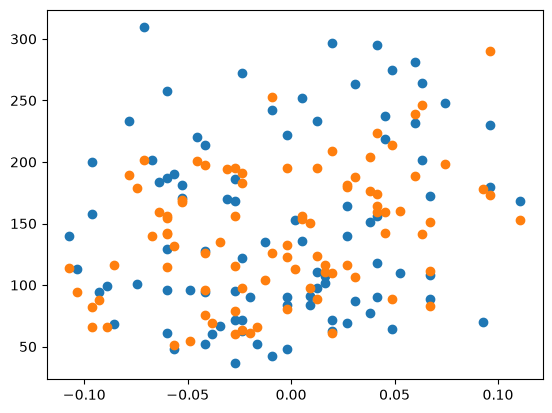

In [19]:
import matplotlib.pyplot as plt

plt.scatter(X_test[:, 0], y_test)
plt.scatter(X_test[:, 0], prediction)
plt.show()

In [ ]:
## ▲그래프: 주황점(예측값)이 파란점(실제값) 근처로 넓게 퍼짐 -> 입력값에 따라 예측값이 달라짐 -> 학습 잘됨

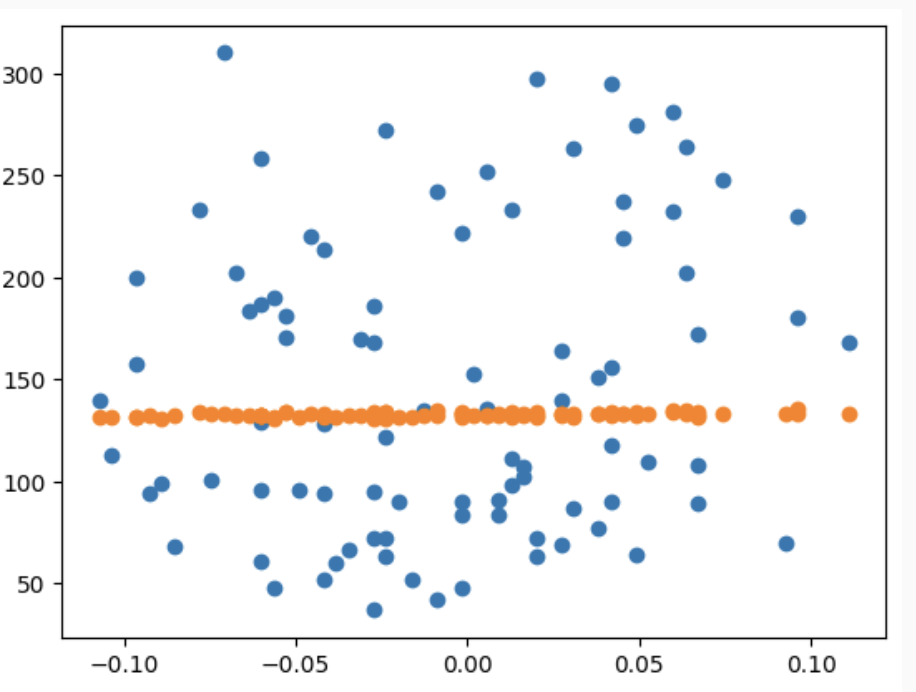

In [ ]:
## 이전 그래프: 입력값에 따른 반응 없이 평균값만 찍음 -> 학습 부족 상태

In [25]:
# 프로젝트 2

In [ ]:
## gdown, pandas 불러오기

In [26]:
import gdown
import pandas as pd

In [27]:
gdown.download('https://drive.google.com/uc?id=1KSQVnefQtRarL-6w5vdd4368hebk3IYG', 'train.csv', quiet=False)
train = pd.read_csv("train.csv") 
train.info()

Downloading...
From: https://drive.google.com/uc?id=1KSQVnefQtRarL-6w5vdd4368hebk3IYG
To: /Users/sooah/train.csv
100%|███████████████████████████████████████| 648k/648k [00:00<00:00, 4.26MB/s]


<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1.2 MB


In [ ]:
## 컬럼을 자료형으로 바꾸고, 6가지 컬럼 생성

In [28]:
train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-null  int32

In [ ]:
## 새로 생성된 컬럼 데이터 개수 시각화

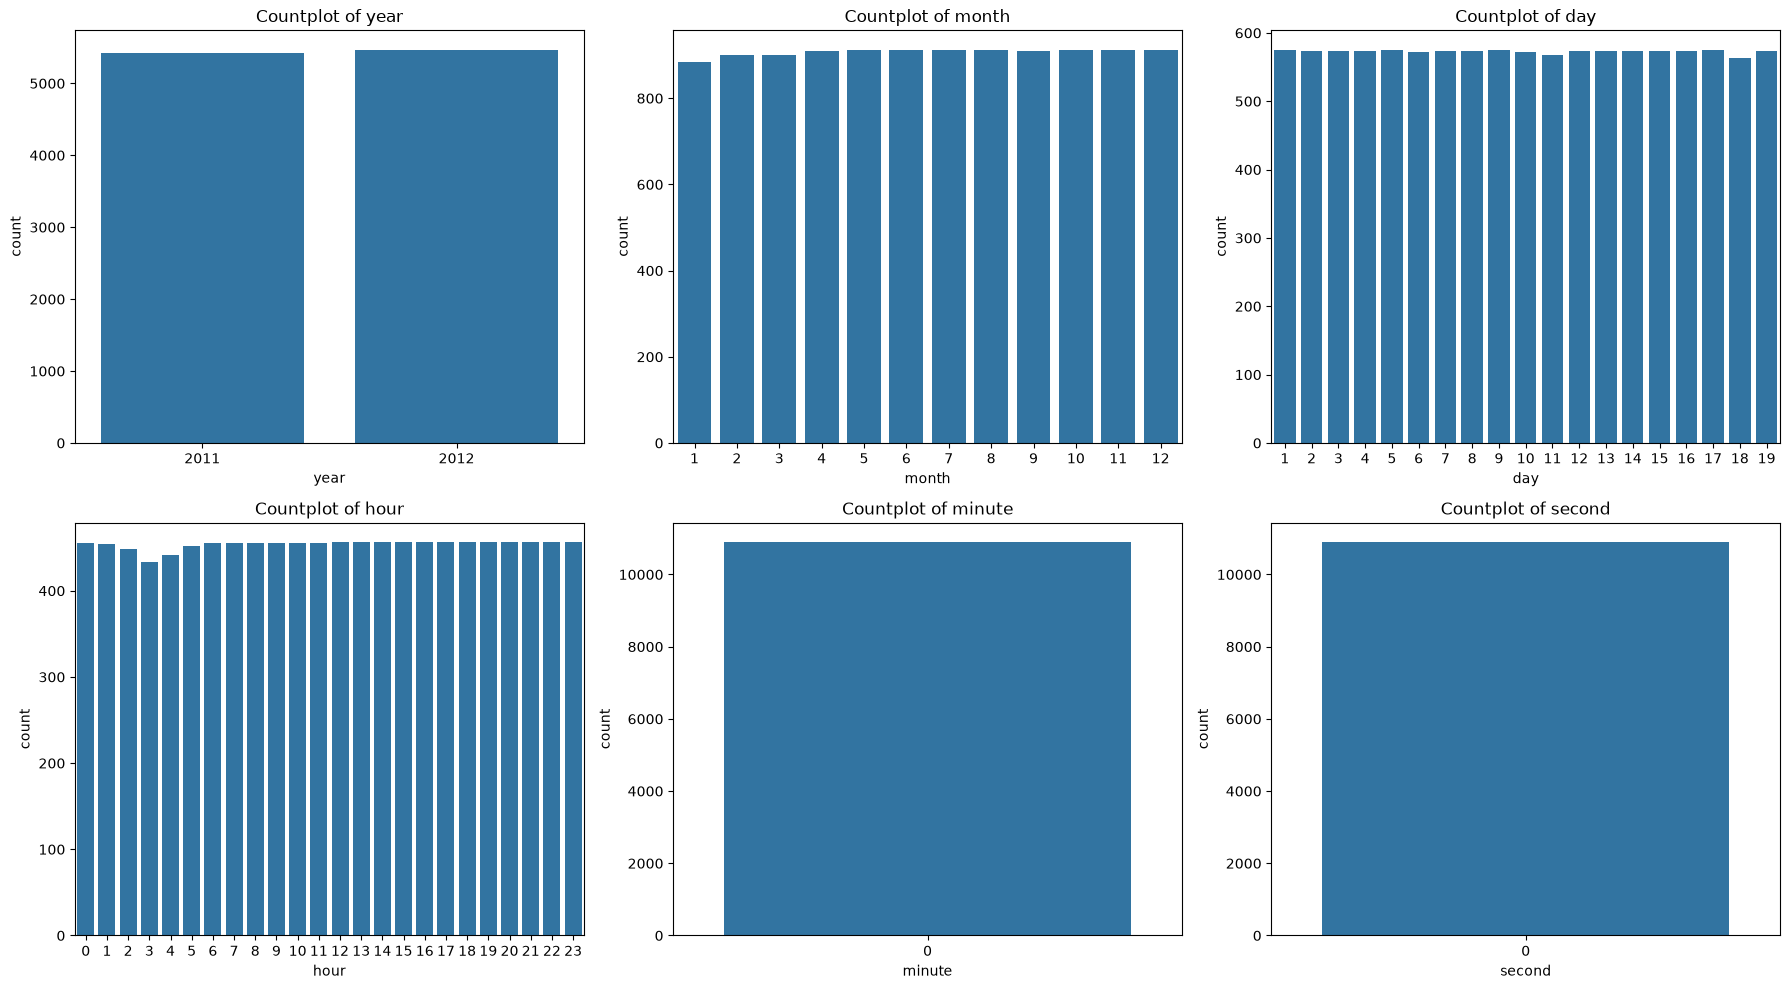

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']
for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()

In [ ]:
## X에 들어갈 컬럼 선택, train, test 데이터 선택
x: train으로 입력할 컬럼들의 features 선택하고 Y: 맞춰야 할 정답 컬럼 고름

In [30]:
features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed']
X = train[features]
y = train['count']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
## 선형회귀 모델 학습
sklearn에서 LinearRegression 모델 가져와서
fit()은 X_train(입력값)과 y_train(정답)을 보고 둘 사이의 관계(가중치, 절편)를 찾음

In [32]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[82.31, 7.71, 0.23,..., 6.52,-2.1 , 0.29]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['year','month','day',...,'temp','humidity','windspeed']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.655e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [ ]:
## 학습 모델로 x test 예측값 출력하기, 손실함수(MSE, RMSE)계산 
[참고
MSE: 실제값에서 예측값 뺀 값. 오차를 제곱한 거라 데이터 단위와 안맞음
RMSE: MSE에 제곱근 씌워 원래대로 돌아옴
정리하면 MSE는 모델학습, 최적화할 때 편하고(계산용), RMSE는 사람이 쉽게 볼 수 있음(해석용)]

In [33]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 19961.901814435474
RMSE: 141.28659460272752


In [34]:
## 예측 결과 시각화 

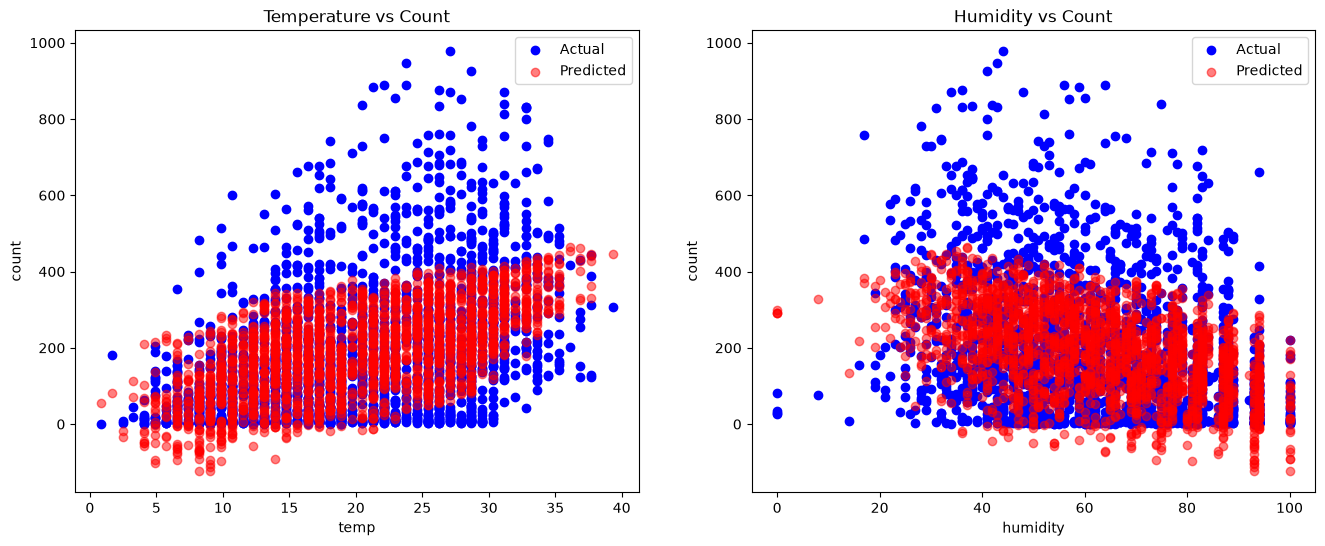

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# temp vs count 시각화
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual')
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()